In [0]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [0]:
# Load data from Unity Catalog table and converting it to pandas
df = spark.table("workspace.default.healthcare_dataset").toPandas()
df.head()

,patient_id,age,bmi,exercise_hours_per_week,smoker,blood_pressure,diabetes
0,1,31,18.3,1.5,0,119.1,0
1,2,44,26.3,3.1,0,120.5,0
2,3,43,24.2,4.8,0,130.3,0
3,4,32,25.0,6.0,0,119.5,0
4,5,28,22.1,4.2,1,127.4,0


In [0]:
# Inspecting the data
print("Shape:", df.shape)
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())

Shape: (6000, 7)

Data Types:
 patient_id                   int64
age                          int64
bmi                        float64
exercise_hours_per_week    float64
smoker                       int64
blood_pressure             float64
diabetes                     int64
dtype: object

Missing Values:
 patient_id                 0
age                        0
bmi                        0
exercise_hours_per_week    0
smoker                     0
blood_pressure             0
diabetes                   0
dtype: int64


In [0]:
# statistical Summary (min, max, mean etc...)
df.describe()

,patient_id,age,bmi,exercise_hours_per_week,smoker,blood_pressure,diabetes
count,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000
mean,3000.500000,51.107333,25.995267,3.012800,0.307000,134.239733,0.090333
std,1732.195139,19.522722,4.960541,1.491802,0.461288,11.234260,0.286683
min,1.000000,18.000000,15.000000,0.000000,0.000000,94.000000,0.000000
25%,1500.750000,34.000000,22.500000,2.000000,0.000000,126.000000,0.000000
50%,3000.500000,51.000000,26.100000,3.000000,0.000000,134.200000,0.000000
75%,4500.250000,68.000000,29.400000,4.000000,1.000000,142.325000,0.000000
max,6000.000000,84.000000,44.900000,8.500000,1.000000,169.700000,1.000000


In [0]:
#dropping patient_id column because it irrelevant for our use case
df = df.drop("patient_id", axis=1)

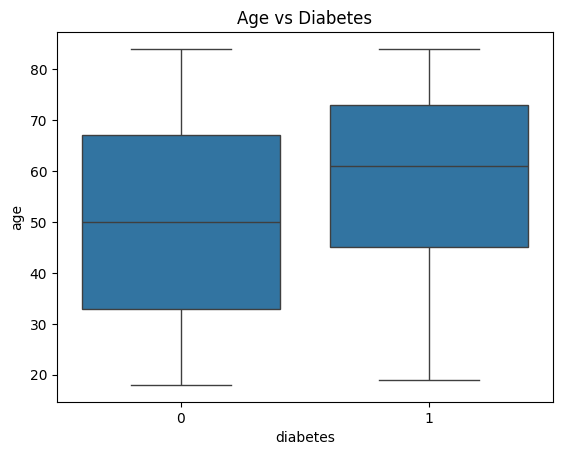

In [0]:
# age distribution for diabetic vs non-diabetic
sns.boxplot(x='diabetes', y='age', data=df)
plt.title("Age vs Diabetes")
plt.show()

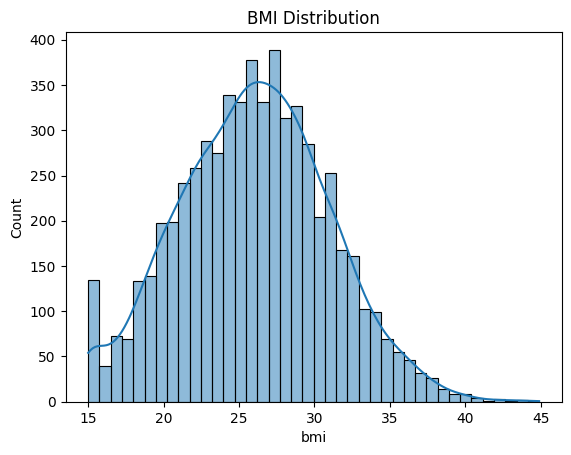

In [0]:
# distribution of BMI
sns.histplot(df['bmi'], kde=True)
plt.title("BMI Distribution")
plt.show()

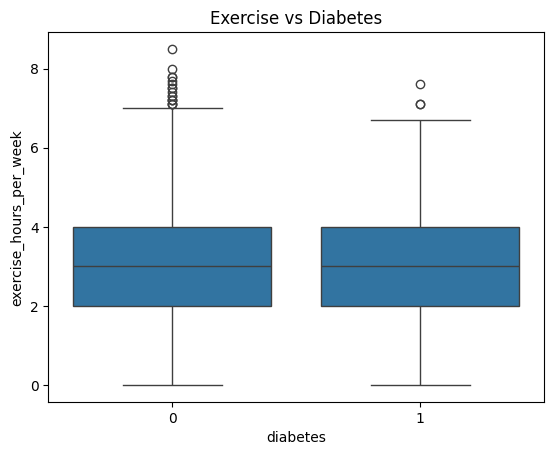

In [0]:
# Exercise vs Diabetes
sns.boxplot(x='diabetes', y='exercise_hours_per_week', data=df)
plt.title("Exercise vs Diabetes")
plt.show()

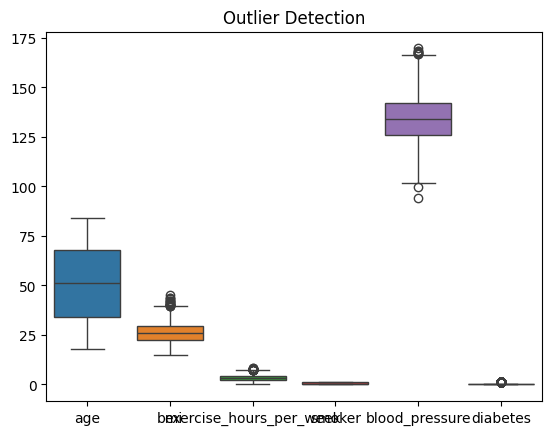

In [0]:
# checking for outliers
sns.boxplot(data=df)
plt.title("Outlier Detection")
plt.show()

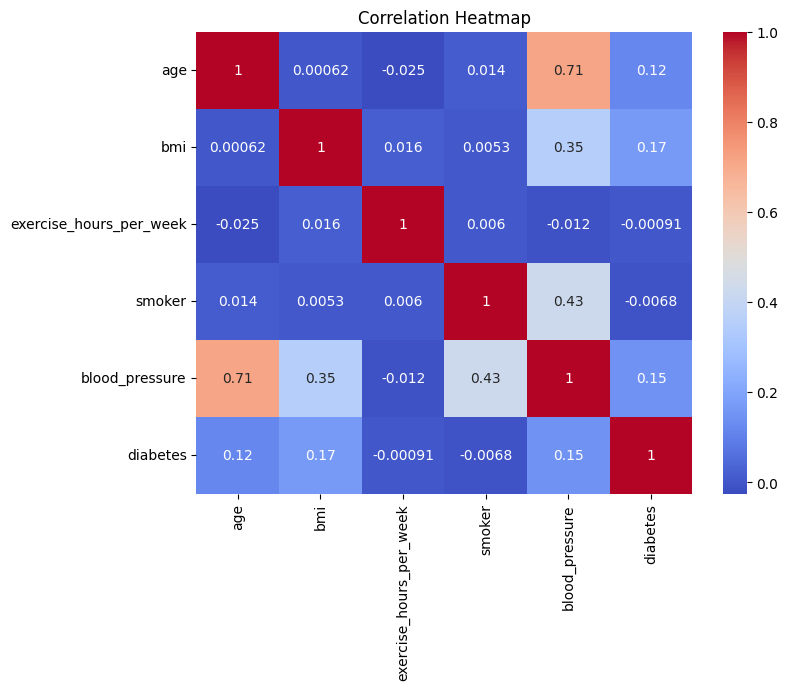

In [0]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [0]:
# Checking for missing values and duplicates
df.isnull().sum()
df.duplicated().sum()

np.int64(0)

In [0]:
# splitting features and target
X = df.drop("diabetes", axis=1)
y = df["diabetes"]

In [0]:
# train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [0]:
# normalising data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [0]:
# Logistic regression
model_lr = LogisticRegression()
model_lr.fit(X_train, y_train)

# training the model
y_pred_lr = model_lr.predict(X_test)

Accuracy: 0.9091666666666667


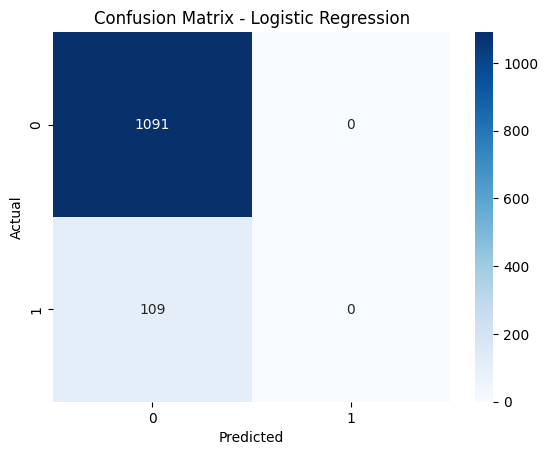


Classification Report:
               precision    recall  f1-score   support

           0       0.91      1.00      0.95      1091
           1       0.00      0.00      0.00       109

    accuracy                           0.91      1200
   macro avg       0.45      0.50      0.48      1200
weighted avg       0.83      0.91      0.87      1200



/databricks/python/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/databricks/python/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/databricks/python/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [0]:
# Evaluation

print("Accuracy:", accuracy_score(y_test, y_pred_lr))

cm = confusion_matrix(y_test, y_pred_lr)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print("\nClassification Report:\n", classification_report(y_test, y_pred_lr))

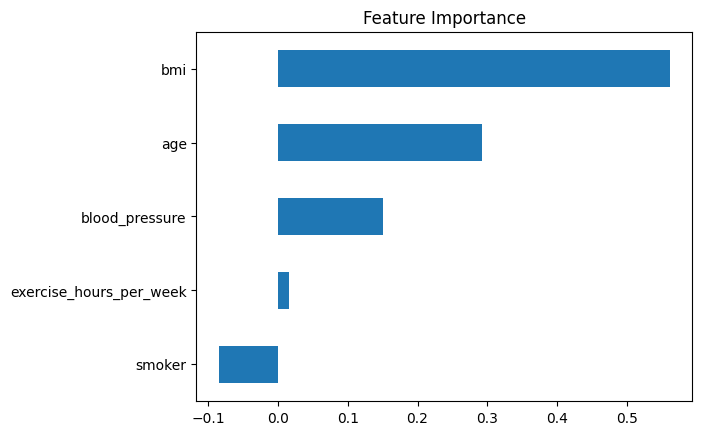

In [0]:
# feature inference
feature_importance = pd.Series(model_lr.coef_[0], index=X.columns)
feature_importance.sort_values().plot(kind='barh')
plt.title("Feature Importance")
plt.show()

In [0]:
# designing the Neural Network and compile
model_nn = Sequential([
    Dense(16, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])

model_nn.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

/local_disk0/.ephemeral_nfs/envs/pythonEnv-d0f6460c-054a-4053-82e5-8724a1316f5e/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [0]:
# training the nueral network

history = model_nn.fit(
    X_train, y_train,
    epochs=20,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)

Epoch 1/20
240/240 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8633 - loss: 0.4484 - val_accuracy: 0.9062 - val_loss: 0.3340
Epoch 2/20
240/240 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9107 - loss: 0.3047 - val_accuracy: 0.9062 - val_loss: 0.2941
Epoch 3/20
240/240 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9107 - loss: 0.2890 - val_accuracy: 0.9062 - val_loss: 0.2853
Epoch 4/20
240/240 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9107 - loss: 0.2851 - val_accuracy: 0.9062 - val_loss: 0.2842
Epoch 5/20
240/240 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9107 - loss: 0.2838 - val_accuracy: 0.9062 - val_loss: 0.2830
Epoch 6/20
240/240 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9107 - loss: 0.2824 - val_accuracy: 0.9062 - val_loss: 0.2838
Epoch 7/20
240/240 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9107 - loss: 0.2822 - val_accuracy: 0.9062 - val_loss: 0.2836
Epoch 8/20
240/240 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9107 - loss: 0.2817 - val_accuracy: 0.

In [0]:
# evaluating the NN and predictng

loss, accuracy_nn = model_nn.evaluate(X_test, y_test)
print("Neural Network Accuracy:", accuracy_nn)

y_pred_nn = (model_nn.predict(X_test) > 0.5).astype("int32")

38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9092 - loss: 0.2783
Neural Network Accuracy: 0.909166693687439
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


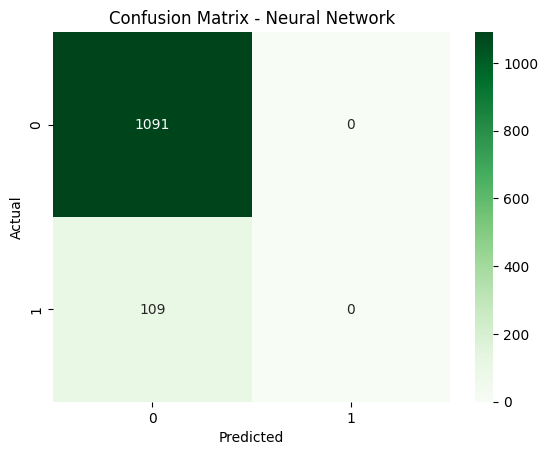


Classification Report:
               precision    recall  f1-score   support

           0       0.91      1.00      0.95      1091
           1       0.00      0.00      0.00       109

    accuracy                           0.91      1200
   macro avg       0.45      0.50      0.48      1200
weighted avg       0.83      0.91      0.87      1200



/databricks/python/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/databricks/python/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/databricks/python/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [0]:
# conufstion matrix of NN

cm_nn = confusion_matrix(y_test, y_pred_nn)

sns.heatmap(cm_nn, annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix - Neural Network")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print("\nClassification Report:\n", classification_report(y_test, y_pred_nn))

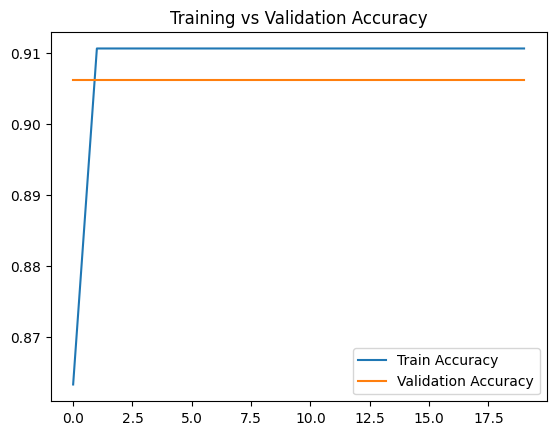

In [0]:
## Training vs Validation Accuracy

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

In [0]:
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Neural Network Accuracy:", accuracy_nn)

Logistic Regression Accuracy: 0.9091666666666667
Neural Network Accuracy: 0.909166693687439
